# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [13]:
!pip install pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package install

,commit,val_bpb,memory_gb,artifact_mb,status,description
0,baseline,1.265738,10.0,15.8,KEEP,baseline (9L 512d 8h 4kv 2xMLP tied-embed)
1,1ce6db7,1.265827,10.0,15.8,DISCARD,LeakyReLU² instead of ReLU² in MLP (no improve...
2,31f0c69,1.268712,10.0,15.8,DISCARD,warmdown 3000 + grad clip 0.3 (worse - warmdow...
3,4ef1cd4,1.268877,10.0,15.8,DISCARD,Muon momentum 0.99 warmup 0.92->1500 (worse - ...
4,9a3379c,1.268903,10.0,15.8,DISCARD,matrix_lr=0.06 scalar_lr=0.06 (too aggressive)
5,3e2ea0a,1.279711,10.7,15.3,DISCARD,10L 480d (worse - width reduction hurts more t...
6,c25c210,1.439684,10.0,15.8,DISCARD,EMA decay=0.997 (broken: bf16 precision kills ...
7,8b35146,1.265735,10.0,15.8,DISCARD,EMA fixed (fp32 GPU periodic decay=0.99) - wor...
8,c2a985c,1.253255,10.0,15.7,KEEP,seq_len 2048 (-0.0125 BPB!)
9,d834ca8,1.253417,10.0,15.7,DISCARD,warmdown 900 (slightly worse than default 1200)


In [14]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    17
KEEP        9

Keep rate: 9/26 = 34.6%


In [15]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (9 total):

  #  0  bpb=1.265738  mem=10.0GB  baseline (9L 512d 8h 4kv 2xMLP tied-embed)
  #  8  bpb=1.253255  mem=10.0GB  seq_len 2048 (-0.0125 BPB!)
  # 12  bpb=1.250462  mem=10.0GB  grad clip 0.3 + seq2048 (-0.0028 from seq2048 alone)
  # 13  bpb=1.244259  mem=10.0GB  Muon WD 0.04 (-0.0062 + artifact shrank to 12.8MB!)
  # 14  bpb=1.243270  mem=11.1GB  10 layers (-0.001 BPB, artifact 14.1MB)
  # 15  bpb=1.238129  mem=12.0GB  11 layers (-0.005 BPB, artifact 15.5MB)
  # 20  bpb=1.237615  mem=12.0GB  orthogonal init (-0.0005 BPB)
  # 22  bpb=1.235480  mem=12.0GB  AdamW WD 0.04 on embed+scalar (-0.0021 BPB)
  # 23  bpb=1.233277  mem=12.0GB  XSA on last 4 layers (-0.0022 BPB)


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

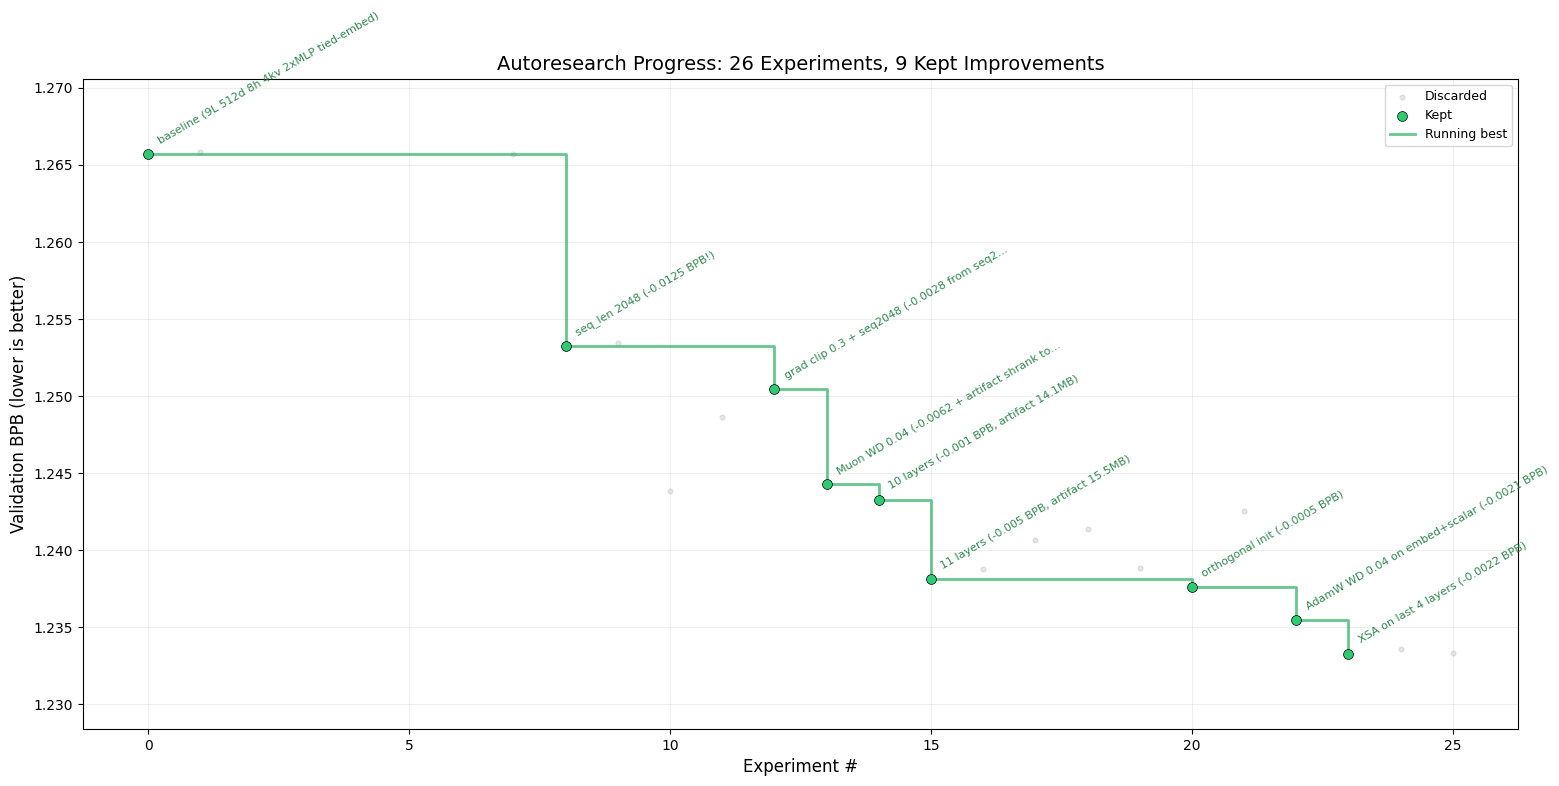

Saved to progress.png


In [16]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [17]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.265738
Best val_bpb:      1.233277
Total improvement: 0.032461 (2.56%)
Best experiment:   XSA on last 4 layers (-0.0022 BPB)

Cumulative effort per improvement:
  Experiment #  0: bpb=1.265738  baseline (9L 512d 8h 4kv 2xMLP tied-embed)
  Experiment #  8: bpb=1.253255  seq_len 2048 (-0.0125 BPB!)
  Experiment # 12: bpb=1.250462  grad clip 0.3 + seq2048 (-0.0028 from seq2048 alone)
  Experiment # 13: bpb=1.244259  Muon WD 0.04 (-0.0062 + artifact shrank to 12.8MB!)
  Experiment # 14: bpb=1.243270  10 layers (-0.001 BPB, artifact 14.1MB)
  Experiment # 15: bpb=1.238129  11 layers (-0.005 BPB, artifact 15.5MB)
  Experiment # 20: bpb=1.237615  orthogonal init (-0.0005 BPB)
  Experiment # 22: bpb=1.235480  AdamW WD 0.04 on embed+scalar (-0.0021 BPB)
  Experiment # 23: bpb=1.233277  XSA on last 4 layers (-0.0022 BPB)


## Top Hits (Kept Experiments by Improvement)

In [18]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.012483  1.253255  seq_len 2048 (-0.0125 BPB!)
   2  +0.006203  1.244259  Muon WD 0.04 (-0.0062 + artifact shrank to 12.8MB!)
   3  +0.005141  1.238129  11 layers (-0.005 BPB, artifact 15.5MB)
   4  +0.002793  1.250462  grad clip 0.3 + seq2048 (-0.0028 from seq2048 alone)
   5  +0.002203  1.233277  XSA on last 4 layers (-0.0022 BPB)
   6  +0.002135  1.235480  AdamW WD 0.04 on embed+scalar (-0.0021 BPB)
   7  +0.000989  1.243270  10 layers (-0.001 BPB, artifact 14.1MB)
   8  +0.000514  1.237615  orthogonal init (-0.0005 BPB)

      +0.032461              TOTAL improvement over baseline
